<a href="https://colab.research.google.com/github/DanishHafeezRana/DeepONET/blob/main/Heat_Equation_DeepONet_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Solving the 1D Heat Equation with DeepONet

This notebook implements a beginner-friendly DeepONet solver for the one-dimensional heat equation



$\frac{\partial u}{\partial t}=\kappa \frac{\partial^2 u}{\partial x^2}, \qquad 0<x<1, \quad 0<t\leq T,
$


with homogeneous Dirichlet boundary conditions

$
u(0,t)=u(1,t)=0,
$

and variable initial condition

$
u(x,0)=u_0(x).
$

The purpose is to learn the **solution operator**

$
\mathcal{G}: u_0(x) \mapsto u(x,t),
$

where the input is an initial temperature profile and the output is the temperature at any requested space-time point $(x,t)$.

The code uses an exact sine-series solution to generate training data. This avoids hallucinated numerical targets and gives a clean verification problem.



## 1. Mathematical problem

We solve the heat equation on the unit interval:

$
u_t = \kappa u_{xx}, \qquad x\in(0,1), \quad t\in[0,T].
$

Here:

- $u(x,t)$ is temperature at position $x$ and time $t$.
- $u_t=\partial u/\partial t$ is the rate of change of temperature with respect to time.
- $u_{xx}=\partial^2u/\partial x^2$ measures spatial curvature of temperature.
- $\kappa>0$ is the thermal diffusivity. Larger $\kappa$ means heat spreads faster.

The boundary conditions are

$
u(0,t)=u(1,t)=0,
$

meaning the two ends of the rod are held at zero temperature.

For initial conditions satisfying the zero boundary behavior, we use finite sine expansions:

$
u_0(x)=\sum_{n=1}^{M} a_n\sin(n\pi x).
$

The exact solution is

$
u(x,t)=\sum_{n=1}^{M} a_n e^{-\kappa (n\pi)^2t}\sin(n\pi x).
$

This exact formula is used only to generate trustworthy training and test data. The DeepONet then learns the operator mapping $(u_0)$ to $(u(x,t)$).


In [1]:

# ============================================================
# 0. Imports
# ============================================================
# This notebook uses PyTorch. Google Colab usually has PyTorch installed.
# If PyTorch is missing, run: !pip install torch

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


In [1]:

# ============================================================
# 1. Configuration
# ============================================================
# You may increase these numbers for a stronger experiment.
# The defaults are chosen to run in a reasonable time on Google Colab.

KAPPA = 0.01          # thermal diffusivity
T_FINAL = 1.0         # final time
N_MODES = 6           # number of sine modes used to generate initial conditions
N_SENSORS = 100       # number of sensors where initial condition is sampled for branch input
LATENT_DIM = 100      # DeepONet latent dimension p

N_TRAIN_FUNCTIONS = 200   # number of training initial conditions
N_TEST_FUNCTIONS = 40     # number of unseen test initial conditions
POINTS_PER_FUNCTION = 80 # space-time query points per function for supervised training

BATCH_SIZE = 2048
EPOCHS = 500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6

# Physics-informed regularization weights.
# Set these to 0.0 if you want a purely data-driven DeepONet.
LAMBDA_DATA = 1.0
LAMBDA_PDE = 1e-4
LAMBDA_IC = 1e-2
LAMBDA_BC = 1e-2

PRINT_EVERY = 50

PDE_BATCH_SIZE = 256  # second derivatives are costly; use a subset for PDE residual



## 2. Data generation using the exact heat equation solution

The initial function is sampled as

$
u_0(x)=\sum_{n=1}^{M}a_n\sin(n\pi x).
$

The heat equation damps high-frequency modes faster because the exponential factor is

$
e^{-\kappa(n\pi)^2t}.
$

Thus, larger values of $n$ decay more quickly. This is one of the central physical meanings of the heat equation: heat smooths out sharp spatial variations over time.


In [5]:

# ============================================================
# 2. Exact solution utilities
# ============================================================

def sample_coefficients(num_functions, n_modes=N_MODES):
    """
    Sample random sine-series coefficients for initial conditions.

    We scale by 1/n^2 so that high-frequency modes are not too large.
    This creates smooth initial temperature profiles.
    """
    coeffs = np.random.normal(loc=0.0, scale=1.0, size=(num_functions, n_modes))
    scale = 1.0 / (np.arange(1, n_modes + 1) ** 2)
    coeffs = coeffs * scale[None, :]
    return coeffs.astype(np.float32)


def heat_solution_from_coeffs(coeffs, x, t, kappa=KAPPA):
    """
    Exact solution of the 1D heat equation with zero boundary conditions.

    Parameters
    ----------
    coeffs : array of shape (B, M)
        Sine coefficients a_n for B different initial conditions.
    x : array of shape (B, 1) or (B,)
        Spatial coordinates.
    t : array of shape (B, 1) or (B,)
        Time coordinates.
    kappa : float
        Thermal diffusivity.

    Returns
    -------
    u : array of shape (B, 1)
        Exact values u(x,t).
    """
    coeffs = np.asarray(coeffs, dtype=np.float32)
    x = np.asarray(x, dtype=np.float32).reshape(-1, 1)
    t = np.asarray(t, dtype=np.float32).reshape(-1, 1)

    modes = np.arange(1, coeffs.shape[1] + 1, dtype=np.float32).reshape(1, -1)
    sine_part = np.sin(modes * np.pi * x)
    decay_part = np.exp(-kappa * (modes * np.pi) ** 2 * t)
    u = np.sum(coeffs * sine_part * decay_part, axis=1, keepdims=True)
    return u.astype(np.float32)


def initial_condition_from_coeffs(coeffs, x):
    """Evaluate u0(x), which is the heat solution at t=0."""
    t0 = np.zeros_like(np.asarray(x).reshape(-1, 1), dtype=np.float32)
    return heat_solution_from_coeffs(coeffs, x, t0, kappa=KAPPA)


In [6]:
import numpy as np

# ============================================================
# 3. Generate branch inputs and supervised training pairs
# ============================================================

# Sensor locations for the branch input.
# The branch network sees u0 at these fixed sensor points.
x_sensors = np.linspace(0.0, 1.0, N_SENSORS, dtype=np.float32).reshape(-1, 1)

# Random initial condition coefficients
coeffs_train = sample_coefficients(N_TRAIN_FUNCTIONS, N_MODES)
coeffs_test = sample_coefficients(N_TEST_FUNCTIONS, N_MODES)

# Branch inputs: u0 evaluated at sensor locations for each function
branch_train = []
for i in range(N_TRAIN_FUNCTIONS):
    c = np.repeat(coeffs_train[i:i+1], N_SENSORS, axis=0)
    u0_vals = initial_condition_from_coeffs(c, x_sensors).reshape(-1)
    branch_train.append(u0_vals)
branch_train = np.asarray(branch_train, dtype=np.float32)

branch_test = []
for i in range(N_TEST_FUNCTIONS):
    c = np.repeat(coeffs_test[i:i+1], N_SENSORS, axis=0)
    u0_vals = initial_condition_from_coeffs(c, x_sensors).reshape(-1)
    branch_test.append(u0_vals)
branch_test = np.asarray(branch_test, dtype=np.float32)

print("Branch train shape:", branch_train.shape)
print("Branch test shape :", branch_test.shape)


Branch train shape: (200, 100)
Branch test shape : (40, 100)


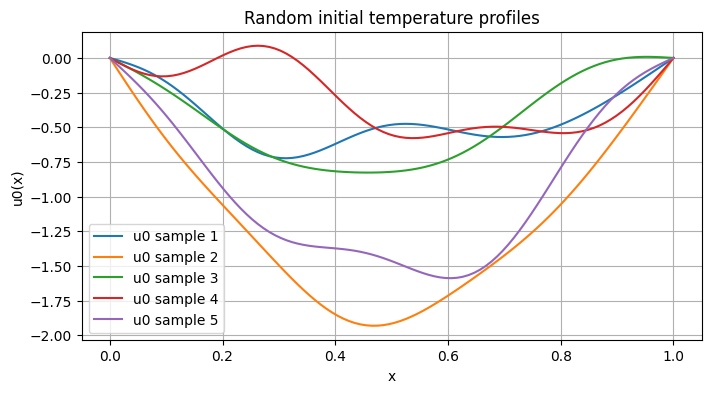

In [11]:
import matplotlib.pyplot as plt

# Visualize a few random initial conditions
plt.figure(figsize=(8, 4))
for i in range(5):
    plt.plot(x_sensors, branch_train[i], label=f"u0 sample {i+1}")
plt.xlabel("x")
plt.ylabel("u0(x)")
plt.title("Random initial temperature profiles")
plt.grid(True)
plt.legend()
plt.show()


In [13]:
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch

def make_supervised_dataset(coeffs, branch_values, points_per_function=POINTS_PER_FUNCTION):
    """
    Create supervised DeepONet training data.

    For each initial condition u0, we sample many query coordinates (x,t).
    The input to DeepONet is:
        branch_input = u0 sampled at sensor locations
        trunk_input  = coordinate pair (x,t)
    The target is:
        u(x,t), computed using the exact heat equation solution.
    """
    n_functions = coeffs.shape[0]
    total_points = n_functions * points_per_function

    function_ids = np.repeat(np.arange(n_functions), points_per_function)
    x_query = np.random.uniform(0.0, 1.0, size=(total_points, 1)).astype(np.float32)
    t_query = np.random.uniform(0.0, T_FINAL, size=(total_points, 1)).astype(np.float32)

    coeffs_for_points = coeffs[function_ids]
    branch_for_points = branch_values[function_ids]
    trunk_for_points = np.concatenate([x_query, t_query], axis=1).astype(np.float32)
    target_u = heat_solution_from_coeffs(coeffs_for_points, x_query, t_query, KAPPA)

    return branch_for_points, trunk_for_points, target_u, function_ids

branch_X, trunk_X, y_u, function_ids = make_supervised_dataset(coeffs_train, branch_train)

print("branch_X:", branch_X.shape)
print("trunk_X :", trunk_X.shape)
print("y_u     :", y_u.shape)

# Convert to PyTorch tensors and DataLoader
train_dataset = TensorDataset(
    torch.tensor(branch_X, dtype=torch.float32),
    torch.tensor(trunk_X, dtype=torch.float32),
    torch.tensor(y_u, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


branch_X: (16000, 100)
trunk_X : (16000, 2)
y_u     : (16000, 1)



## 3. DeepONet model

DeepONet learns an operator. Here, the operator maps an initial condition $u_0$ to a solution value $u(x,t)$:

$
\mathcal{G}(u_0)(x,t)=u(x,t).
$

In this implementation:

- The branch input is $u_0$ sampled at fixed sensor locations.
- The trunk input is the coordinate pair $(x,t)$.
- The model output is the predicted solution $\widehat{u}(x,t)$.

The final DeepONet combination is

$
\widehat{u}(x,t)=\sum_{k=1}^{p} b_k(u_0)t_k(x,t)+b_0,
$

where $b_k(u_0)$ are branch features and $t_k(x,t)$ are trunk features.


In [20]:
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 4. DeepONet architecture
# ============================================================

class MLP(nn.Module):
    """Simple fully connected neural network."""
    def __init__(self, layer_sizes, activation=nn.Tanh):
        super().__init__()
        layers = []
        for i in range(len(layer_sizes) - 2):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            layers.append(activation())
        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    """
    DeepONet for the heat equation solution operator.

    branch_input: sampled initial condition u0 at sensor points, shape (B, N_SENSORS)
    trunk_input : coordinate pair (x,t), shape (B, 2)
    output      : predicted u(x,t), shape (B, 1)
    """
    def __init__(self, n_sensors=N_SENSORS, latent_dim=LATENT_DIM):
        super().__init__()

        # Branch network learns a representation of the input function u0.
        self.branch_net = MLP([n_sensors, 128, 128, latent_dim], activation=nn.Tanh)

        # Trunk network learns a representation of the query coordinate (x,t).
        self.trunk_net = MLP([2, 128, 128, latent_dim], activation=nn.Tanh)

        # Scalar trainable bias term.
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        branch_features = self.branch_net(branch_input)  # (B, p)
        trunk_features = self.trunk_net(trunk_input)     # (B, p)

        # Inner product between branch and trunk features.
        u_pred = torch.sum(branch_features * trunk_features, dim=1, keepdim=True) + self.bias
        return u_pred


model = DeepONet().to(DEVICE)
print(model)


DeepONet(
  (branch_net): MLP(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=100, bias=True)
    )
  )
  (trunk_net): MLP(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=100, bias=True)
    )
  )
)



## 4. Loss function

The main training loss is supervised mean squared error:

$
\mathcal{L}_{\text{data}}
=\frac{1}{N}\sum_i\left|\widehat{u}(x_i,t_i)-u(x_i,t_i)\right|^2.
$

We also include optional physics-informed terms:

### PDE residual

The heat equation says

$
u_t-\kappa u_{xx}=0.
$

So for the neural prediction \(\widehat{u}\), define

$
R(x,t)=\frac{\partial \widehat{u}}{\partial t}-\kappa\frac{\partial^2\widehat{u}}{\partial x^2}.
$

The PDE loss is

$
\mathcal{L}_{\text{PDE}}=\frac{1}{N_c}\sum_j |R(x_j,t_j)|^2.
$

### Initial condition loss

At $t=0$, the solution must satisfy

$
u(x,0)=u_0(x).
$

### Boundary condition loss

At the boundaries, the solution must satisfy

$
u(0,t)=u(1,t)=0.
$

The total loss is

$
\mathcal{L}=\lambda_{\text{data}}\mathcal{L}_{\text{data}}
+\lambda_{\text{PDE}}\mathcal{L}_{\text{PDE}}
+\lambda_{\text{IC}}\mathcal{L}_{\text{IC}}
+\lambda_{\text{BC}}\mathcal{L}_{\text{BC}}.
$


In [21]:

# ============================================================
# 5. Physics-informed losses
# ============================================================

def pde_residual_loss(model, branch_batch, x_batch, t_batch, kappa=KAPPA):
    """
    Computes mean squared heat equation residual:
        R = u_t - kappa * u_xx

    Autograd is used to differentiate the DeepONet output with respect to x and t.
    """
    coords = torch.cat([x_batch, t_batch], dim=1).clone().detach().requires_grad_(True)
    u_pred = model(branch_batch, coords)

    # First derivatives: du/dx and du/dt
    grad_u = torch.autograd.grad(
        outputs=u_pred,
        inputs=coords,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    # Second derivative: d^2u/dx^2
    grad_u_x = torch.autograd.grad(
        outputs=u_x,
        inputs=coords,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]
    u_xx = grad_u_x[:, 0:1]

    residual = u_t - kappa * u_xx
    return torch.mean(residual ** 2)


def initial_condition_loss(model, coeffs_np, branch_np, batch_size=512):
    """
    Enforce u(x,0)=u0(x) on random initial-condition points.
    """
    n_functions = coeffs_np.shape[0]
    ids = np.random.randint(0, n_functions, size=batch_size)
    x0 = np.random.uniform(0.0, 1.0, size=(batch_size, 1)).astype(np.float32)
    t0 = np.zeros((batch_size, 1), dtype=np.float32)

    target = initial_condition_from_coeffs(coeffs_np[ids], x0)
    branch = branch_np[ids]
    coords = np.concatenate([x0, t0], axis=1)

    branch_t = torch.tensor(branch, dtype=torch.float32, device=DEVICE)
    coords_t = torch.tensor(coords, dtype=torch.float32, device=DEVICE)
    target_t = torch.tensor(target, dtype=torch.float32, device=DEVICE)

    pred = model(branch_t, coords_t)
    return torch.mean((pred - target_t) ** 2)


def boundary_condition_loss(model, branch_np, batch_size=512):
    """
    Enforce u(0,t)=0 and u(1,t)=0 on random boundary points.
    """
    n_functions = branch_np.shape[0]
    ids = np.random.randint(0, n_functions, size=batch_size)

    t = np.random.uniform(0.0, T_FINAL, size=(batch_size, 1)).astype(np.float32)
    x_left = np.zeros((batch_size // 2, 1), dtype=np.float32)
    x_right = np.ones((batch_size - batch_size // 2, 1), dtype=np.float32)
    x = np.vstack([x_left, x_right]).astype(np.float32)

    t = t[:x.shape[0]]
    ids = ids[:x.shape[0]]

    branch = branch_np[ids]
    coords = np.concatenate([x, t], axis=1)
    target = np.zeros((x.shape[0], 1), dtype=np.float32)

    branch_t = torch.tensor(branch, dtype=torch.float32, device=DEVICE)
    coords_t = torch.tensor(coords, dtype=torch.float32, device=DEVICE)
    target_t = torch.tensor(target, dtype=torch.float32, device=DEVICE)

    pred = model(branch_t, coords_t)
    return torch.mean((pred - target_t) ** 2)


In [22]:

# ============================================================
# 6. Training loop
# ============================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=100
)

history = {
    "total_loss": [],
    "data_loss": [],
    "pde_loss": [],
    "ic_loss": [],
    "bc_loss": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_total = 0.0
    epoch_data = 0.0
    epoch_pde = 0.0
    epoch_ic = 0.0
    epoch_bc = 0.0
    n_batches = 0

    for branch_b, trunk_b, target_b in train_loader:
        branch_b = branch_b.to(DEVICE)
        trunk_b = trunk_b.to(DEVICE)
        target_b = target_b.to(DEVICE)

        optimizer.zero_grad()

        pred_b = model(branch_b, trunk_b)
        data_loss = torch.mean((pred_b - target_b) ** 2)

        # PDE residual uses a subset of the batch because second derivatives are expensive.
        # This keeps the notebook practical while still showing how physics is enforced.
        pde_n = min(PDE_BATCH_SIZE, branch_b.shape[0])
        pde_idx = torch.randperm(branch_b.shape[0], device=DEVICE)[:pde_n]
        branch_pde = branch_b[pde_idx]
        trunk_pde = trunk_b[pde_idx]
        x_b = trunk_pde[:, 0:1]
        t_b = trunk_pde[:, 1:2]
        pde_loss = pde_residual_loss(model, branch_pde, x_b, t_b, KAPPA)

        ic_loss = initial_condition_loss(model, coeffs_train, branch_train, batch_size=256)
        bc_loss = boundary_condition_loss(model, branch_train, batch_size=256)

        total_loss = (
            LAMBDA_DATA * data_loss
            + LAMBDA_PDE * pde_loss
            + LAMBDA_IC * ic_loss
            + LAMBDA_BC * bc_loss
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_total += float(total_loss.detach().cpu())
        epoch_data += float(data_loss.detach().cpu())
        epoch_pde += float(pde_loss.detach().cpu())
        epoch_ic += float(ic_loss.detach().cpu())
        epoch_bc += float(bc_loss.detach().cpu())
        n_batches += 1

    avg_total = epoch_total / n_batches
    avg_data = epoch_data / n_batches
    avg_pde = epoch_pde / n_batches
    avg_ic = epoch_ic / n_batches
    avg_bc = epoch_bc / n_batches

    history["total_loss"].append(avg_total)
    history["data_loss"].append(avg_data)
    history["pde_loss"].append(avg_pde)
    history["ic_loss"].append(avg_ic)
    history["bc_loss"].append(avg_bc)

    scheduler.step(avg_total)

    if epoch % PRINT_EVERY == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {avg_total:.4e} | "
            f"Data: {avg_data:.4e} | "
            f"PDE: {avg_pde:.4e} | "
            f"IC: {avg_ic:.4e} | "
            f"BC: {avg_bc:.4e}"
        )


Epoch     1 | Total: 2.0868e-01 | Data: 2.0262e-01 | PDE: 2.2339e-02 | IC: 2.0841e-01 | BC: 3.9758e-01
Epoch    50 | Total: 1.0973e-02 | Data: 1.0356e-02 | PDE: 3.9325e-03 | IC: 1.9358e-02 | BC: 4.2319e-02
Epoch   100 | Total: 2.6080e-03 | Data: 2.4583e-03 | PDE: 3.4490e-03 | IC: 6.9311e-03 | BC: 8.0087e-03
Epoch   150 | Total: 2.5505e-03 | Data: 2.4108e-03 | PDE: 3.0136e-03 | IC: 6.4726e-03 | BC: 7.4690e-03
Epoch   200 | Total: 3.3913e-03 | Data: 3.2576e-03 | PDE: 3.4274e-03 | IC: 6.3999e-03 | BC: 6.9358e-03
Epoch   250 | Total: 1.3298e-03 | Data: 1.2645e-03 | PDE: 4.1201e-03 | IC: 3.8438e-03 | BC: 2.6474e-03
Epoch   300 | Total: 1.2915e-03 | Data: 1.2306e-03 | PDE: 3.7357e-03 | IC: 3.5847e-03 | BC: 2.4610e-03
Epoch   350 | Total: 1.0238e-03 | Data: 9.6189e-04 | PDE: 3.5669e-03 | IC: 3.5245e-03 | BC: 2.6307e-03
Epoch   400 | Total: 8.0494e-04 | Data: 7.5347e-04 | PDE: 3.5806e-03 | IC: 2.8758e-03 | BC: 2.2353e-03
Epoch   450 | Total: 7.8895e-04 | Data: 7.3780e-04 | PDE: 3.1815e-03 | IC

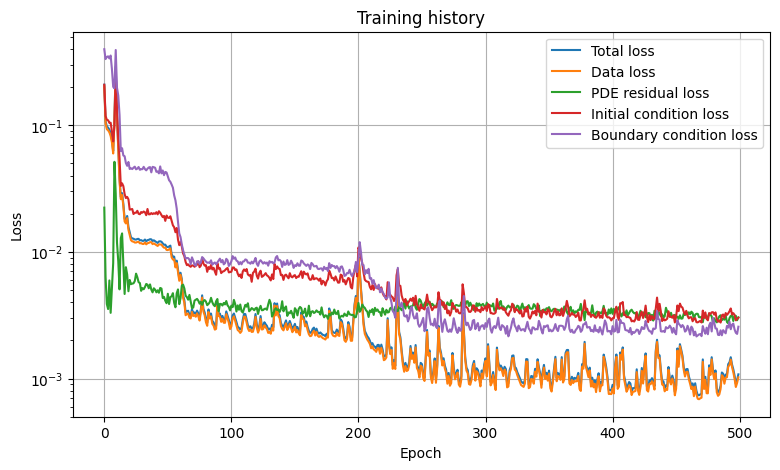

In [23]:

# Plot training losses
plt.figure(figsize=(9, 5))
plt.semilogy(history["total_loss"], label="Total loss")
plt.semilogy(history["data_loss"], label="Data loss")
plt.semilogy(history["pde_loss"], label="PDE residual loss")
plt.semilogy(history["ic_loss"], label="Initial condition loss")
plt.semilogy(history["bc_loss"], label="Boundary condition loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.grid(True)
plt.legend()
plt.show()



## 5. Testing the learned operator on unseen initial conditions

The important point of DeepONet is not only to solve one initial condition. It learns the mapping

$
u_0 \mapsto u(x,t).
$

Therefore, we test the trained model on new initial conditions that were not seen during training.


In [24]:

# ============================================================
# 7. Evaluation on unseen functions
# ============================================================

@torch.no_grad()
def predict_solution_grid(model, branch_input, x_grid, t_grid):
    """
    Predict u(x,t) on a full x-t grid for one initial condition.
    """
    X, T = np.meshgrid(x_grid, t_grid)
    coords = np.stack([X.reshape(-1), T.reshape(-1)], axis=1).astype(np.float32)

    branch_repeated = np.repeat(branch_input.reshape(1, -1), coords.shape[0], axis=0).astype(np.float32)

    branch_t = torch.tensor(branch_repeated, dtype=torch.float32, device=DEVICE)
    coords_t = torch.tensor(coords, dtype=torch.float32, device=DEVICE)

    pred = model(branch_t, coords_t).cpu().numpy().reshape(len(t_grid), len(x_grid))
    return pred


def exact_solution_grid(coeff, x_grid, t_grid):
    """Exact solution on an x-t grid for one initial condition."""
    X, T = np.meshgrid(x_grid, t_grid)
    coords_x = X.reshape(-1, 1).astype(np.float32)
    coords_t = T.reshape(-1, 1).astype(np.float32)
    coeff_repeated = np.repeat(coeff.reshape(1, -1), coords_x.shape[0], axis=0)
    exact = heat_solution_from_coeffs(coeff_repeated, coords_x, coords_t, KAPPA)
    return exact.reshape(len(t_grid), len(x_grid))


def relative_l2_error(pred, true):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-12)

# Grid used for evaluation
x_eval = np.linspace(0.0, 1.0, 101, dtype=np.float32)
t_eval = np.linspace(0.0, T_FINAL, 101, dtype=np.float32)

rel_errors = []
for i in range(N_TEST_FUNCTIONS):
    pred_grid = predict_solution_grid(model, branch_test[i], x_eval, t_eval)
    true_grid = exact_solution_grid(coeffs_test[i], x_eval, t_eval)
    rel_errors.append(relative_l2_error(pred_grid, true_grid))

rel_errors = np.array(rel_errors)
print("Mean relative L2 error on unseen initial conditions:", rel_errors.mean())
print("Median relative L2 error:", np.median(rel_errors))
print("Worst relative L2 error:", rel_errors.max())


Mean relative L2 error on unseen initial conditions: 0.08943514
Median relative L2 error: 0.059052683
Worst relative L2 error: 0.3442692


Relative L2 error for plotted sample: 0.05458612


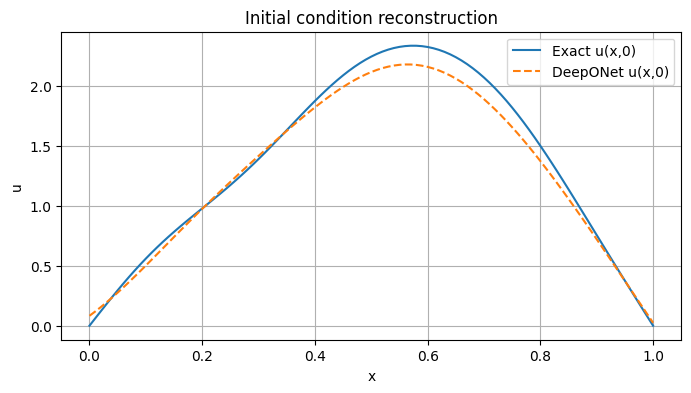

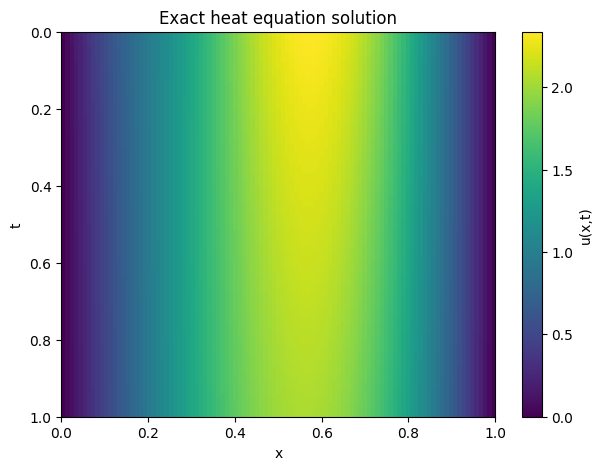

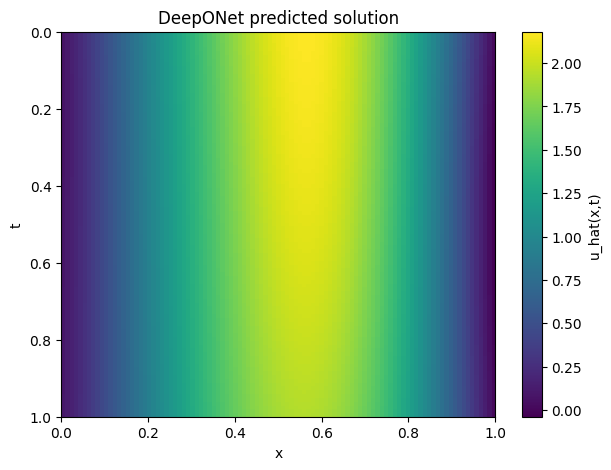

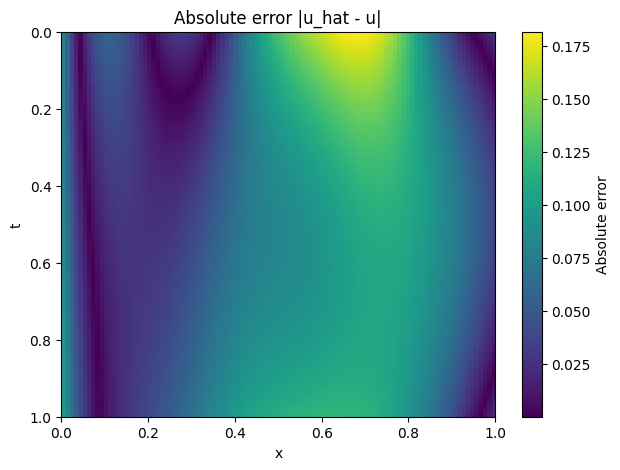

In [25]:

# ============================================================
# 8. Visual comparison for one unseen initial condition
# ============================================================

test_id = 0
pred_grid = predict_solution_grid(model, branch_test[test_id], x_eval, t_eval)
true_grid = exact_solution_grid(coeffs_test[test_id], x_eval, t_eval)
abs_error = np.abs(pred_grid - true_grid)

print("Relative L2 error for plotted sample:", relative_l2_error(pred_grid, true_grid))

plt.figure(figsize=(8, 4))
plt.plot(x_eval, true_grid[0], label="Exact u(x,0)")
plt.plot(x_eval, pred_grid[0], "--", label="DeepONet u(x,0)")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Initial condition reconstruction")
plt.grid(True)
plt.legend()
plt.show()

# Heat maps
plt.figure(figsize=(7, 5))
plt.imshow(true_grid, extent=[0, 1, T_FINAL, 0], aspect="auto")
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact heat equation solution")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(pred_grid, extent=[0, 1, T_FINAL, 0], aspect="auto")
plt.colorbar(label="u_hat(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("DeepONet predicted solution")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(abs_error, extent=[0, 1, T_FINAL, 0], aspect="auto")
plt.colorbar(label="Absolute error")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute error |u_hat - u|")
plt.show()


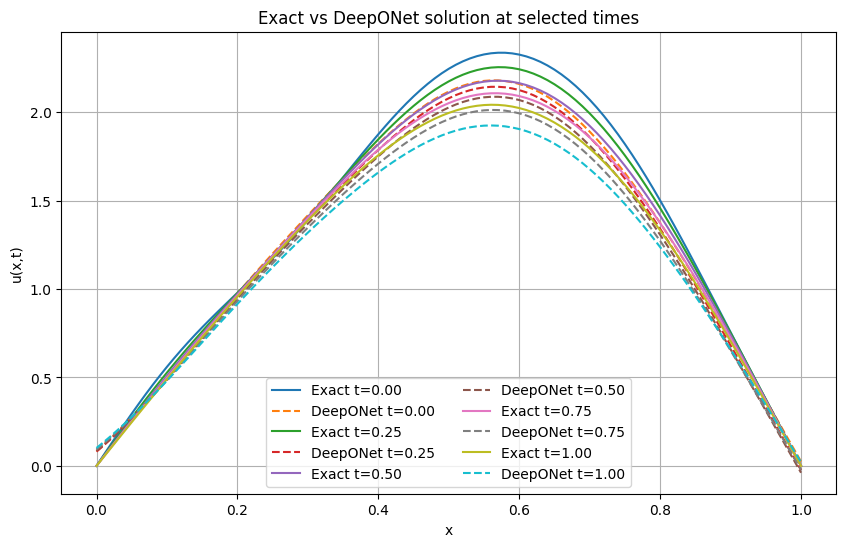

In [26]:

# Plot solution curves at selected times
selected_times = [0.0, 0.25, 0.50, 0.75, 1.0]

plt.figure(figsize=(10, 6))
for time_value in selected_times:
    idx = np.argmin(np.abs(t_eval - time_value))
    plt.plot(x_eval, true_grid[idx], label=f"Exact t={t_eval[idx]:.2f}")
    plt.plot(x_eval, pred_grid[idx], "--", label=f"DeepONet t={t_eval[idx]:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Exact vs DeepONet solution at selected times")
plt.grid(True)
plt.legend(ncol=2)
plt.show()


In [27]:

# ============================================================
# 9. PDE residual diagnostic on the trained model
# ============================================================
# This checks whether the learned solution approximately satisfies u_t = kappa u_xx.

model.eval()

# Choose one branch input and random collocation points.
num_residual_points = 1000
branch_one = torch.tensor(
    np.repeat(branch_test[test_id:test_id+1], num_residual_points, axis=0),
    dtype=torch.float32,
    device=DEVICE
)

x_col = torch.rand(num_residual_points, 1, device=DEVICE)
t_col = T_FINAL * torch.rand(num_residual_points, 1, device=DEVICE)

res_loss = pde_residual_loss(model, branch_one, x_col, t_col, KAPPA)
print("Mean squared PDE residual on random collocation points:", float(res_loss.detach().cpu()))


Mean squared PDE residual on random collocation points: 0.006675316486507654



## 6. What this notebook demonstrates

This notebook shows that DeepONet can be trained to approximate the solution operator of the heat equation:

$
\mathcal{G}: u_0(x)\mapsto u(x,t).
$

The model is not trained for one fixed initial condition only. It is trained over many initial conditions sampled from sine series. After training, the same DeepONet can predict the solution for unseen initial profiles.

Important points:

1. The heat equation smooths the initial condition over time.
2. High-frequency sine modes decay faster than low-frequency modes.
3. DeepONet learns the operator from initial profile to solution value.
4. The branch input represents the initial condition.
5. The trunk input represents the query location $(x,t)$.
6. Physics-informed residuals can be added to encourage the model to satisfy $u_t-\kappa u_{xx}=0$.

For stronger experiments, increase `N_TRAIN_FUNCTIONS`, `POINTS_PER_FUNCTION`, and `EPOCHS`. For faster testing, reduce them.
